![image.png](https://i.imgur.com/a3uAqnb.png)

#  Self-Supervised Contrastive Learning with SimCLR




SimCLR learns visual representations by comparing two augmented views of the same image.



- **Original image $x$:** The input image before augmentation.
- **Augmented views $x_i$ and $x_j$:** Two different transformations of the same image.
- **Encoder $f_\theta$:** A shared CNN, such as ResNet, that extracts representations.
- **Representations $h_i$ and $h_j$:** Feature vectors produced by the encoder.
- **Projection head $g_\theta$:** A shared MLP that maps the representations into a contrastive space.
- **Projected features $z_i$ and $z_j$:** Vectors used to calculate the contrastive loss.


- Two views of the same image form a **positive pair** and are pulled closer together.
- Views from different images form **negative pairs** and are pushed farther apart.

$$
x
\;\longrightarrow\;
\{x_i, x_j\}
\;\xrightarrow{\,f_\theta\,}\;
\{h_i, h_j\}
\;\xrightarrow{\,g_\theta\,}\;
\{z_i, z_j\}
$$

The contrastive loss increases the similarity between $z_i$ and $z_j$ while reducing their similarity to representations from other images in the batch.

![SimCLR Framework](https://i.imgur.com/Pzqfqrr.png)

## 1. Download and Load the STL-10 Dataset

STL-10 contains RGB images from 10 classes.  
For SimCLR, we use the **unlabeled split** for self-supervised pretraining.  
The labeled training and test splits will later be used for evaluation.

In [ ]:
from torchvision.datasets import STL10

# Unlabeled split for SimCLR pretraining
unlabeled_dataset = STL10(
    root="./data",
    split="unlabeled",
    download=True
)

# Labeled training split
train_dataset = STL10(
    root="./data",
    split="train",
    download=True
)

# Labeled test split
test_dataset = STL10(
    root="./data",
    split="test",
    download=True
)

print("Download complete.")
print("Unlabeled:", len(unlabeled_dataset))
print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

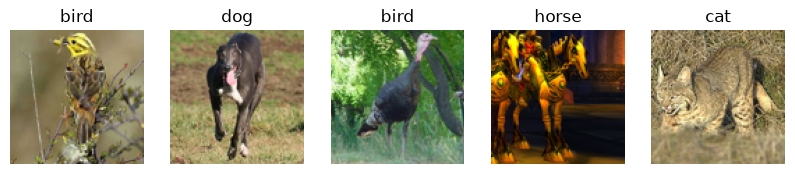

In [ ]:
import matplotlib.pyplot as plt
from torchvision.datasets import STL10

dataset = STL10(root="./data", split="train", download=True)

plt.figure(figsize=(10, 4))

for i in range(5):
    image, label = dataset[i]

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(dataset.classes[label])
    plt.axis("off")

plt.show()

## 2. Create Two Augmented Views for SimCLR

SimCLR learns from two different augmented versions of the same image.

For each original image, we create:

* **View 1:** the first random augmentation
* **View 2:** the second random augmentation

Because both views come from the same image, they form a **positive pair**.



In [ ]:
from torchvision import transforms

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(96),
    transforms.RandomHorizontalFlip(),

    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.4,
            contrast=0.4,
            saturation=0.4,
            hue=0.1
        )
    ], p=0.8),

    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor()
])

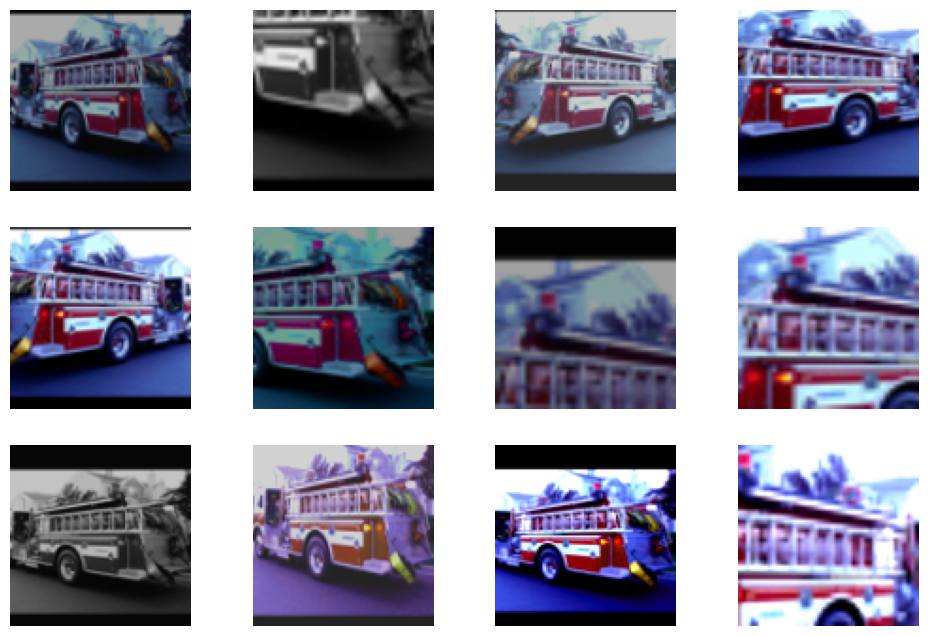

In [ ]:
image, _ = dataset[5]

plt.figure(figsize=(12, 8))

for i in range(12):
    view = simclr_transform(image)

    plt.subplot(3, 4, i + 1)
    plt.imshow(view.permute(1, 2, 0))
    plt.axis("off")

plt.show()

## 3. Create Positive Image Pairs

Each image is transformed twice to create two related views for SimCLR training.


In [ ]:
class TwoViews:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, image):
        return self.transform(image), self.transform(image)

In [ ]:
import os
import torch.utils.data as data

NUM_WORKERS = min(4, os.cpu_count() or 1)

unlabeled_dataset = STL10(
    root="./data",
    split="unlabeled",
    download=True,
    transform=TwoViews(simclr_transform)
)

train_loader = data.DataLoader(
    unlabeled_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Unlabeled images:", len(unlabeled_dataset))
print("Number of batches:", len(train_loader))

Unlabeled images: 100000
Number of batches: 781



## 4. Build the SimCLR Model

SimCLR uses a CNN encoder to extract image features, followed by a projection head used during contrastive learning.


In [ ]:
import torch.nn as nn
import torchvision

class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()


        self.encoder = torchvision.models.resnet18(weights=None)

        feature_dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        # Projection head
        self.projector = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projector(features)
        return features, projections

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimCLRModel(projection_dim=128).to(device)

print(model)

SimCLRModel(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
print("Encoder final layer:")
print(model.encoder.fc)

print("\nProjection head:")
print(model.projector)

Encoder final layer:
Identity()

Projection head:
Sequential(
  (0): Linear(in_features=512, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=128, bias=True)
)


## 5. Define the Contrastive Loss

The NT-Xent loss makes the two views of the same image similar and separates them from views of other images.


In [ ]:
import torch.nn.functional as F
def nt_xent_loss(z1, z2, temperature=0.1):
    batch_size = z1.size(0)

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    z = torch.cat([z1, z2], dim=0)

    logits = z @ z.T
    logits = logits / temperature

    self_mask = torch.eye(
        2 * batch_size,
        dtype=torch.bool,
        device=z.device
    )
# A1 index 0 -> A2 index 3
# B1 index 1 -> B2 index 4
# C1 index 2 -> C2 index 5
# A2 index 3 -> A1 index 0
# B2 index 4 -> B1 index 1
# C2 index 5 -> C1 index 2
    logits = logits.masked_fill(self_mask, float("-inf"))

    targets = torch.arange(
        2 * batch_size,
        device=z.device
    )

    targets = (targets + batch_size) % (2 * batch_size)

    return F.cross_entropy(logits, targets)

## 6. Train SimCLR

The model learns by minimizing the contrastive loss between two augmented views of each image.


In [ ]:
import torch.optim as optim
from tqdm import tqdm
from torch.nn import functional as F

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

EPOCHS = 10
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for views, _ in progress_bar:
        view1, view2 = views

        view1 = view1.to(device, non_blocking=True)
        view2 = view2.to(device, non_blocking=True)

        optimizer.zero_grad()

        _, z1 = model(view1)
        _, z2 = model(view2)

        loss = nt_xent_loss(
            z1,
            z2,
            temperature=0.1
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    average_loss = total_loss / len(train_loader)
    train_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} - "
        f"Average loss: {average_loss:.4f}"
    )

Epoch 1/10: 100%|██████████| 781/781 [03:02<00:00,  4.28it/s, loss=2.0426]


Epoch 1/10 - Average loss: 3.0222


Epoch 2/10: 100%|██████████| 781/781 [03:02<00:00,  4.28it/s, loss=1.4396]


Epoch 2/10 - Average loss: 1.8983


Epoch 3/10: 100%|██████████| 781/781 [03:00<00:00,  4.32it/s, loss=1.5736]


...

Epoch 8/10 - Average loss: 1.0988


Epoch 9/10: 100%|██████████| 781/781 [02:53<00:00,  4.51it/s, loss=1.0391]


Epoch 9/10 - Average loss: 1.0554


Epoch 10/10: 100%|██████████| 781/781 [03:16<00:00,  3.97it/s, loss=0.9518]

Epoch 10/10 - Average loss: 1.0227


## 7. Save the Trained SimCLR Model

We save the encoder and projection head so the learned representations can be reused later.

In [ ]:
torch.save(
    model.state_dict(),
    "simclr_stl10.pth"
)

print("Model saved.")

Model saved.


## 8. Prepare Labeled Data for Linear Evaluation

The SimCLR encoder will be frozen, and a linear classifier will be trained using labeled STL-10 images.

In [ ]:
eval_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = STL10(
    root="./data",
    split="train",
    download=True,
    transform=eval_transform
)

test_dataset = STL10(
    root="./data",
    split="test",
    download=True,
    transform=eval_transform
)

train_eval_loader = data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_eval_loader = data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

Training images: 5000
Test images: 8000


## 9. Linear Evaluation

The SimCLR encoder is frozen, and only a linear classifier is trained. This measures how useful the learned representations are.

In [ ]:

for parameter in model.encoder.parameters():
    parameter.requires_grad = False

model.encoder.eval()


linear_classifier = nn.Linear(512, 10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    linear_classifier.parameters(),
    lr=1e-3
)

In [ ]:
LINEAR_EPOCHS = 10
linear_losses = []

for epoch in range(LINEAR_EPOCHS):
    linear_classifier.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_eval_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Extract frozen SimCLR features
        with torch.no_grad():
            features = model.encoder(images)

        logits = linear_classifier(features)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / len(train_eval_loader)
    accuracy = 100 * correct / total

    linear_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{LINEAR_EPOCHS} - "
        f"Loss: {average_loss:.4f} - "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/10 - Loss: 1.6316 - Accuracy: 40.44%
Epoch 2/10 - Loss: 1.1180 - Accuracy: 61.10%
Epoch 3/10 - Loss: 1.0404 - Accuracy: 63.32%
Epoch 4/10 - Loss: 0.9871 - Accuracy: 64.66%
Epoch 5/10 - Loss: 0.9446 - Accuracy: 65.62%
Epoch 6/10 - Loss: 0.9400 - Accuracy: 66.14%
Epoch 7/10 - Loss: 0.9191 - Accuracy: 66.82%
Epoch 8/10 - Loss: 0.9069 - Accuracy: 67.68%
Epoch 9/10 - Loss: 0.8895 - Accuracy: 68.16%
Epoch 10/10 - Loss: 0.8799 - Accuracy: 68.06%


## 10. Evaluate the Linear Classifier

The frozen SimCLR encoder and the trained linear classifier are evaluated on unseen test images.

In [ ]:
linear_classifier.eval()
model.encoder.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_eval_loader:
        images = images.to(device)
        labels = labels.to(device)

        features = model.encoder(images)
        logits = linear_classifier(features)

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 65.51%


## 11. Random Encoder Baseline

We compare SimCLR with a randomly initialized ResNet-18.  
Both encoders are frozen, and only a linear classifier is trained.

In [ ]:
import torchvision

random_encoder = torchvision.models.resnet18(weights=None)

feature_dim = random_encoder.fc.in_features
random_encoder.fc = nn.Identity()

random_encoder = random_encoder.to(device)

# Freeze random encoder
for parameter in random_encoder.parameters():
    parameter.requires_grad = False

random_encoder.eval()

random_classifier = nn.Linear(feature_dim, 10).to(device)

random_optimizer = optim.Adam(
    random_classifier.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

In [ ]:
RANDOM_EPOCHS = 10

for epoch in range(RANDOM_EPOCHS):
    random_classifier.train()

    correct = 0
    total = 0
    total_loss = 0.0

    for images, labels in train_eval_loader:
        images = images.to(device)
        labels = labels.to(device)

        random_optimizer.zero_grad()

        with torch.no_grad():
            features = random_encoder(images)

        logits = random_classifier(features)
        loss = criterion(logits, labels)

        loss.backward()
        random_optimizer.step()

        total_loss += loss.item()

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    average_loss = total_loss / len(train_eval_loader)

    print(
        f"Epoch {epoch + 1}/{RANDOM_EPOCHS} - "
        f"Loss: {average_loss:.4f} - "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/10 - Loss: 2.3133 - Accuracy: 10.84%
Epoch 2/10 - Loss: 2.2901 - Accuracy: 14.28%
Epoch 3/10 - Loss: 2.2682 - Accuracy: 17.02%
Epoch 4/10 - Loss: 2.2535 - Accuracy: 17.22%
Epoch 5/10 - Loss: 2.2300 - Accuracy: 20.94%
Epoch 6/10 - Loss: 2.2168 - Accuracy: 21.78%
Epoch 7/10 - Loss: 2.1985 - Accuracy: 22.56%
Epoch 8/10 - Loss: 2.1809 - Accuracy: 22.24%
Epoch 9/10 - Loss: 2.1666 - Accuracy: 25.76%
Epoch 10/10 - Loss: 2.1597 - Accuracy: 23.76%


In [ ]:
random_classifier.eval()
random_encoder.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_eval_loader:
        images = images.to(device)
        labels = labels.to(device)

        features = random_encoder(images)
        logits = random_classifier(features)

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

random_test_accuracy = 100 * correct / total

print(f"Random Encoder Test Accuracy: {random_test_accuracy:.2f}%")
print(f"SimCLR Test Accuracy: {test_accuracy:.2f}%")

Random Encoder Test Accuracy: 27.00%
SimCLR Test Accuracy: 65.51%


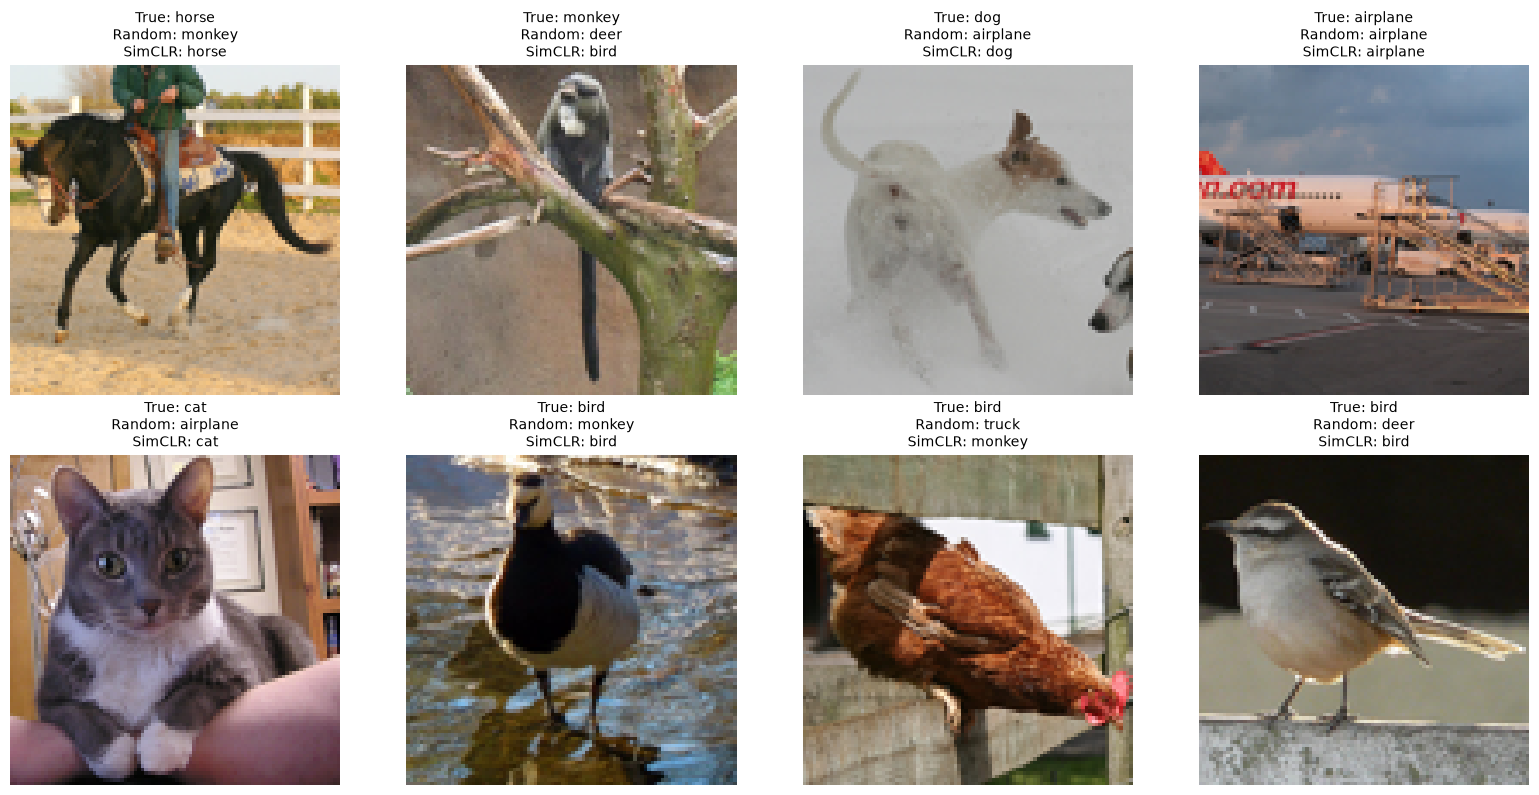

In [ ]:
import matplotlib.pyplot as plt

class_names = test_dataset.classes


images, labels = next(iter(test_eval_loader))

images_gpu = images.to(device)

random_encoder.eval()
random_classifier.eval()
model.encoder.eval()
linear_classifier.eval()

with torch.no_grad():

    random_features = random_encoder(images_gpu)
    random_logits = random_classifier(random_features)
    random_predictions = random_logits.argmax(dim=1).cpu()


    simclr_features = model.encoder(images_gpu)
    simclr_logits = linear_classifier(simclr_features)
    simclr_predictions = simclr_logits.argmax(dim=1).cpu()


plt.figure(figsize=(16, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))

    true_name = class_names[labels[i]]
    random_name = class_names[random_predictions[i]]
    simclr_name = class_names[simclr_predictions[i]]

    plt.title(
        f"True: {true_name}\n"
        f"Random: {random_name}\n"
        f"SimCLR: {simclr_name}",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Exercises

* Change the temperature to `0.05` and `0.5`. Explain how it affects the contrast between positive and negative pairs.
* Train the classifier using fewer labeled images and study how SimCLR performs with limited labels.
* Compare logistic regression and a linear neural-network layer
* Compare a frozen SimCLR encoder with fine-tuning the last ResNet block.
* Remove one augmentation and identify which transformation is most important.

Contributed by :Lama Ayash